# Milestone 3: Machine Learning Model Development and Optimization

In this notebook, we will:
1. Load the daily features dataset created in Milestone 2.
2. Define standard time-series evaluation splits (`TimeSeriesSplit`).
3. Train and cross-validate three model classes:
   - Baseline: Random Forest Regressor
   - Machine Learning: XGBoost Regressor
   - Statistical: SARIMAX (Seasonal Autoregressive Integrated Moving Average with Exogenous Regressors)
4. Compare model performance.
5. Tune hyperparameters for our best-performing model (XGBoost).
6. Track all model training, parameters, and metrics using **MLflow**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import mlflow
import mlflow.sklearn
import os

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Load data
df = pd.read_csv('../data/processed/features_sales.csv', parse_dates=['order_purchase_timestamp'], index_col='order_purchase_timestamp')
df = df.sort_index()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (700, 16)


,total_sales,total_items,total_orders,day_of_week,month,quarter,is_weekend,is_holiday,total_sales_lag_1,total_sales_lag_7,total_sales_lag_14,total_sales_lag_30,total_sales_rolling_avg_7,total_sales_rolling_std_7,total_sales_rolling_avg_30,total_sales_rolling_std_30
order_purchase_timestamp,,,,,,,,,,,,,,,,
2016-10-04,9571.16,67,58,1,10,4,0,0,441.98,0.0,0.0,72.89,1430.448571,3593.493385,338.270333,1745.811366
2016-10-05,6856.56,52,39,2,10,4,0,0,9571.16,0.0,0.0,0.00,2409.957143,4044.741671,566.822333,2110.682642
2016-10-06,6295.72,55,46,3,10,4,0,0,6856.56,0.0,0.0,0.00,3309.345714,4118.830174,776.679667,2351.611576
2016-10-07,6728.25,50,43,4,10,4,0,0,6295.72,0.0,0.0,0.00,4270.524286,4001.221892,1000.954667,2584.310840
2016-10-08,8306.86,43,38,5,10,4,1,0,6728.25,0.0,0.0,0.00,5457.218571,3747.345389,1277.850000,2899.199799


In [3]:
target_col = 'total_sales'
feature_cols = [col for col in df.columns if col not in [target_col, 'total_items', 'total_orders']]

X = df[feature_cols]
y = df[target_col]

print("Features to use:", feature_cols)
print("Target:", target_col)

Features to use: ['day_of_week', 'month', 'quarter', 'is_weekend', 'is_holiday', 'total_sales_lag_1', 'total_sales_lag_7', 'total_sales_lag_14', 'total_sales_lag_30', 'total_sales_rolling_avg_7', 'total_sales_rolling_std_7', 'total_sales_rolling_avg_30', 'total_sales_rolling_std_30']
Target: total_sales


In [4]:
# Set MLflow experiment
mlflow.set_experiment("Sales_Forecasting_Notebook")

def evaluate_model_cv(model, X, y, model_name="Model"):
    tscv = TimeSeriesSplit(n_splits=5)
    
    maes = []
    rmses = []
    r2s = []
    
    print(f"=== Cross-Validating {model_name} ===")
    for fold, (train_index, test_index) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # Fit model
        model.fit(X_train, y_train)
        
        # Predict
        preds = model.predict(X_test)
        
        # Metrics
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        
        print(f"Fold {fold+1} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")
        
    print(f"\nOverall Results for {model_name}:")
    print(f"Mean MAE: {np.mean(maes):.2f}")
    print(f"Mean RMSE: {np.mean(rmses):.2f}")
    print(f"Mean R2: {np.mean(r2s):.2f}\n")
    return np.mean(maes), np.mean(rmses), np.mean(r2s)

2026/07/09 16:14:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/09 16:14:58 INFO mlflow.store.db.utils: Updating database tables
2026/07/09 16:14:59 INFO mlflow.tracking.fluent: Experiment with name 'Sales_Forecasting_Notebook' does not exist. Creating a new experiment.


In [5]:
# Train baseline Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_mae, rf_rmse, rf_r2 = evaluate_model_cv(rf_model, X, y, "Random Forest Baseline")

# Log Random Forest to MLflow
with mlflow.start_run(run_name="RF_Baseline"):
    mlflow.log_params({"n_estimators": 100, "max_depth": 10, "model_type": "RandomForest"})
    mlflow.log_metrics({"mae": rf_mae, "rmse": rf_rmse, "r2": rf_r2})
    rf_model.fit(X, y)
    mlflow.sklearn.log_model(rf_model, "random_forest_model")
    print("Baseline Random Forest logged successfully.")

=== Cross-Validating Random Forest Baseline ===
Fold 1 - MAE: 3738.00, RMSE: 4769.84, R2: -0.13
Fold 2 - MAE: 3209.50, RMSE: 4258.38, R2: 0.34
Fold 3 - MAE: 7180.65, RMSE: 14656.86, R2: 0.05
Fold 4 - MAE: 5227.66, RMSE: 6541.90, R2: 0.22
Fold 5 - MAE: 5097.42, RMSE: 6394.04, R2: 0.71

Overall Results for Random Forest Baseline:
Mean MAE: 4890.65
Mean RMSE: 7324.20
Mean R2: 0.24



2026/07/09 16:15:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/09 16:15:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline Random Forest logged successfully.


In [6]:
# Train XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_mae, xgb_rmse, xgb_r2 = evaluate_model_cv(xgb_model, X, y, "XGBoost")

# Log XGBoost to MLflow
with mlflow.start_run(run_name="XGB_Baseline"):
    mlflow.log_params({"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1, "model_type": "XGBoost"})
    mlflow.log_metrics({"mae": xgb_mae, "rmse": xgb_rmse, "r2": xgb_r2})
    xgb_model.fit(X, y)
    mlflow.sklearn.log_model(xgb_model, "xgb_model")
    print("Baseline XGBoost logged successfully.")

=== Cross-Validating XGBoost ===
Fold 1 - MAE: 3788.72, RMSE: 4928.35, R2: -0.21
Fold 2 - MAE: 3439.08, RMSE: 4560.36, R2: 0.24
Fold 3 - MAE: 7975.78, RMSE: 15288.09, R2: -0.03
Fold 4 - MAE: 4883.37, RMSE: 6059.92, R2: 0.33
Fold 5 - MAE: 6052.72, RMSE: 7358.73, R2: 0.61

Overall Results for XGBoost:
Mean MAE: 5227.93
Mean RMSE: 7639.09
Mean R2: 0.19



2026/07/09 16:15:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/09 16:15:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline XGBoost logged successfully.


In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMAX walk-forward validation (on the last split fold for fair visual comparison)
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(df):
    train_idx, test_idx = train_index, test_index

train_data = df.iloc[train_idx]
test_data = df.iloc[test_idx]

print("Fitting SARIMAX model on historical sales...")
sarima_model = SARIMAX(train_data['total_sales'], 
                      exog=train_data[['is_holiday', 'is_weekend']], 
                      order=(1,1,1), 
                      seasonal_order=(1,1,1,7),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
sarima_results = sarima_model.fit(disp=False)

# Forecast on test fold
sarima_preds = sarima_results.predict(start=test_data.index[0], 
                                      end=test_data.index[-1],
                                      exog=test_data[['is_holiday', 'is_weekend']])

# Calculate metrics for SARIMAX
sarima_mae = mean_absolute_error(test_data['total_sales'], sarima_preds)
sarima_rmse = np.sqrt(mean_squared_error(test_data['total_sales'], sarima_preds))
sarima_r2 = r2_score(test_data['total_sales'], sarima_preds)

print(f"SARIMAX Fold 5 - MAE: {sarima_mae:.2f}, RMSE: {sarima_rmse:.2f}, R2: {sarima_r2:.2f}")

# Log SARIMAX to MLflow
with mlflow.start_run(run_name="SARIMAX_Model"):
    mlflow.log_params({"order": "(1,1,1)", "seasonal_order": "(1,1,1,7)", "model_type": "SARIMAX"})
    mlflow.log_metrics({"mae": sarima_mae, "rmse": sarima_rmse, "r2": sarima_r2})
    print("SARIMAX model logged successfully.")

Fitting SARIMAX model on historical sales...


c:\Users\Mayer_R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Mayer_R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMAX Fold 5 - MAE: 21262.27, RMSE: 24411.10, R2: -3.25
SARIMAX model logged successfully.


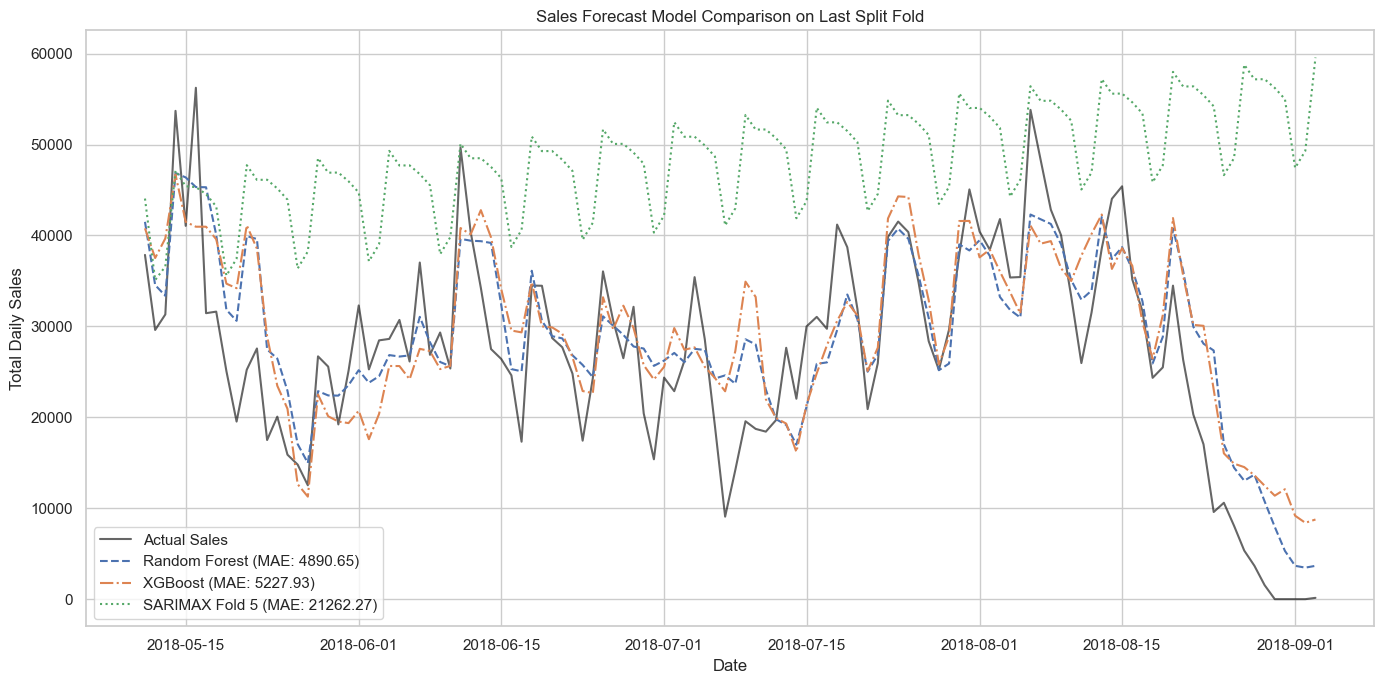

In [8]:
# Generate predictions for Random Forest and XGBoost on the same last fold
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# Plot actual vs predicted
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Sales', color='black', alpha=0.6)
plt.plot(y_test.index, rf_preds, label=f'Random Forest (MAE: {rf_mae:.2f})', linestyle='--')
plt.plot(y_test.index, xgb_preds, label=f'XGBoost (MAE: {xgb_mae:.2f})', linestyle='-.')
plt.plot(y_test.index, sarima_preds, label=f'SARIMAX Fold 5 (MAE: {sarima_mae:.2f})', linestyle=':')
plt.title('Sales Forecast Model Comparison on Last Split Fold')
plt.xlabel('Date')
plt.ylabel('Total Daily Sales')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV

print("Running Grid Search on XGBoost hyperparameters...")
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2]
}

# Use TimeSeriesSplit in Grid Search
tscv = TimeSeriesSplit(n_splits=3)
grid_search = GridSearchCV(estimator=xgb.XGBRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=tscv,
                           scoring='neg_mean_absolute_error',
                           n_jobs=-1)

grid_search.fit(X, y)

best_params = grid_search.best_params_
print(f"Best hyperparameters found: {best_params}")

# Evaluate best tuned model
tuned_xgb = grid_search.best_estimator_
tuned_mae, tuned_rmse, tuned_r2 = evaluate_model_cv(tuned_xgb, X, y, "Tuned XGBoost")

# Log Tuned XGBoost to MLflow
with mlflow.start_run(run_name="Tuned_XGBoost"):
    mlflow.log_params(best_params)
    mlflow.log_metrics({"mae": tuned_mae, "rmse": tuned_rmse, "r2": tuned_r2})
    tuned_xgb.fit(X, y)
    mlflow.sklearn.log_model(tuned_xgb, "best_xgb_model")
    print("Tuned XGBoost logged to MLflow successfully.")

Running Grid Search on XGBoost hyperparameters...
Best hyperparameters found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
=== Cross-Validating Tuned XGBoost ===
Fold 1 - MAE: 4008.82, RMSE: 5234.13, R2: -0.36
Fold 2 - MAE: 3079.06, RMSE: 4201.74, R2: 0.36
Fold 3 - MAE: 7333.21, RMSE: 14694.66, R2: 0.04
Fold 4 - MAE: 4639.46, RMSE: 5789.23, R2: 0.39


2026/07/09 16:15:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/09 16:15:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Fold 5 - MAE: 5319.36, RMSE: 6492.06, R2: 0.70

Overall Results for Tuned XGBoost:
Mean MAE: 4875.98
Mean RMSE: 7282.36
Mean R2: 0.22

Tuned XGBoost logged to MLflow successfully.


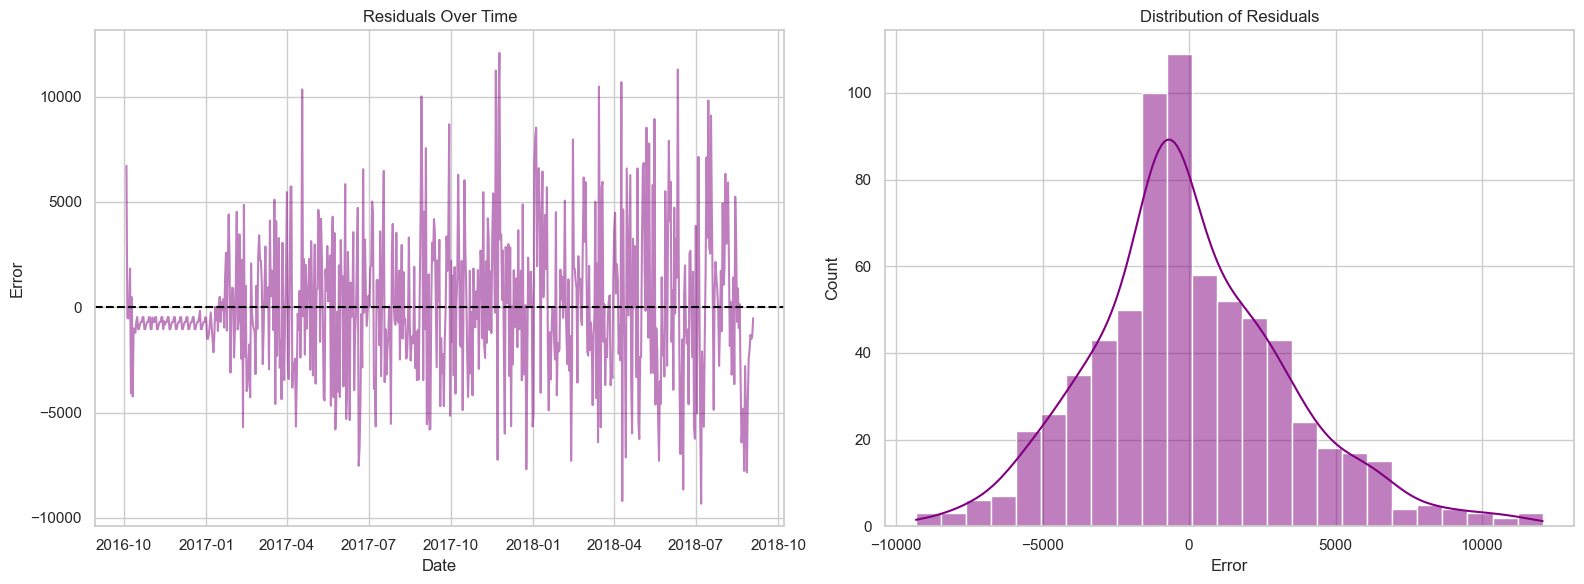

In [10]:
# Predict on full dataset
y_pred = tuned_xgb.predict(X)
residuals = y - y_pred

# Residual Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuals over time
axes[0].plot(residuals.index, residuals.values, color='purple', alpha=0.5)
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_title('Residuals Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Error')

# Distribution of residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Error')

plt.tight_layout()
plt.savefig('residuals_plots.png')
plt.show()